# **Library**

In [1]:
# Importing the libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# **Load Data**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [3]:
import os
os.listdir(path)

['IMDB Dataset.csv']

In [4]:
# First, we get the data
file_path = os.path.join(path,'IMDB Dataset.csv')
df = pd.read_csv(file_path)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
print(df.shape)
print(df['sentiment'].value_counts())

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [8]:
df['sentiment'][0]

'positive'

# **Data Analysis (Exploration & Visualization)**

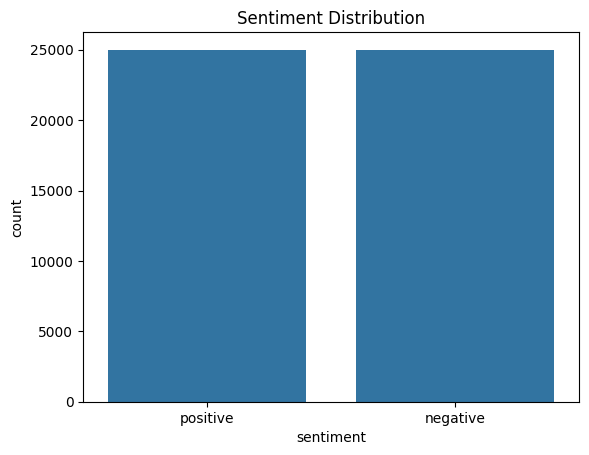

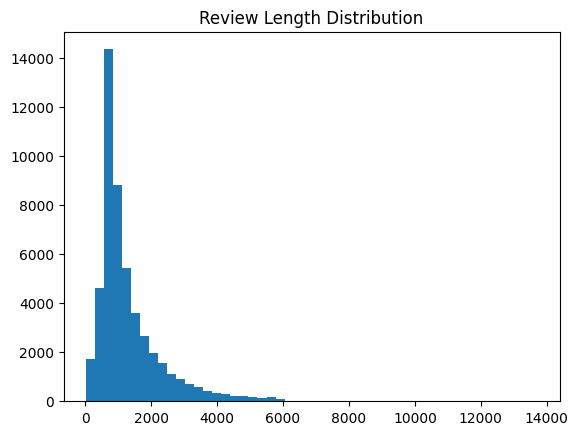

In [9]:

sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

df['length'] = df['review'].apply(len)

plt.hist(df['length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [10]:
from collections import Counter

# Data Split
positive_reviews = df[df['sentiment'] == 'positive']['review']
negative_reviews = df[df['sentiment'] == 'negative']['review']

def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

pos_words = get_top_words(positive_reviews)
neg_words = get_top_words(negative_reviews)

print("Top Positive Words:", pos_words[:10])
print("Top Negative Words:", neg_words[:10])

Top Positive Words: [('the', 291927), ('and', 165943), ('a', 155775), ('of', 149178), ('to', 128343), ('is', 108168), ('in', 90427), ('that', 62449), ('I', 62223), ('it', 53378)]
Top Negative Words: [('the', 276808), ('a', 151185), ('and', 135976), ('of', 134447), ('to', 133507), ('is', 94888), ('in', 79554), ('I', 70275), ('that', 64369), ('this', 62112)]


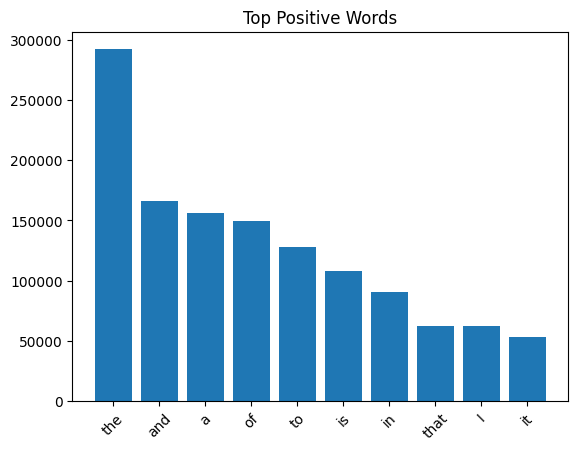

In [11]:
words, counts = zip(*pos_words[:10])
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Positive Words")
plt.show()

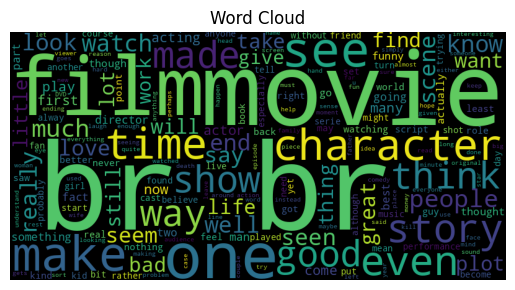

In [12]:
from wordcloud import WordCloud

text = ' '.join(df['review'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [13]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print(df['sentiment'].head())

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64


# **Text Cleaning**

We preprocess the raw reviews by:

* Removing HTML tags
* Removing punctuation and special characters
* Converting text to lowercase

This step ensures cleaner and more consistent input for the model.

In [14]:
import re

def clean_text(text):
    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # lowercase
    text = text.lower()

    return text

df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


# **Data Preprocessing**

In [15]:
# Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['clean_review'])

sequences = tokenizer.texts_to_sequences(df['clean_review'])

In [16]:
# Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X = pad_sequences(sequences, maxlen=max_length)
y =df['sentiment']

In [17]:
from sklearn.model_selection import train_test_split

# First split: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(35000, 200) (7500, 200) (7500, 200)


# **Build RNN Model**

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

model = Sequential()

# Embedding
model.add(Embedding(input_dim=10000, output_dim=64, input_length=200))
# RNN
model.add(SimpleRNN(64, return_sequences=False))
# Regularization
model.add(Dropout(0.5))
# Output
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 42s 72ms/step - accuracy: 0.6232 - loss: 0.6228 - val_accuracy: 0.7771 - val_loss: 0.4754
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - accuracy: 0.7428 - loss: 0.5305 - val_accuracy: 0.5991 - val_loss: 0.6476
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - accuracy: 0.7273 - loss: 0.5369 - val_accuracy: 0.7733 - val_loss: 0.4789
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.7246 - loss: 0.5364 - val_accuracy: 0.7171 - val_loss: 0.5514
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.8077 - loss: 0.4367 - val_accuracy: 0.8029 - val_loss: 0.4558


In [21]:
test_loss, test_acc_rnn = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc_rnn)

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7939 - loss: 0.4637
Test Accuracy: 0.7938666939735413


235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
              precision    recall  f1-score   support

           0       0.83      0.74      0.78      3722
           1       0.77      0.85      0.81      3778

    accuracy                           0.79      7500
   macro avg       0.80      0.79      0.79      7500
weighted avg       0.80      0.79      0.79      7500



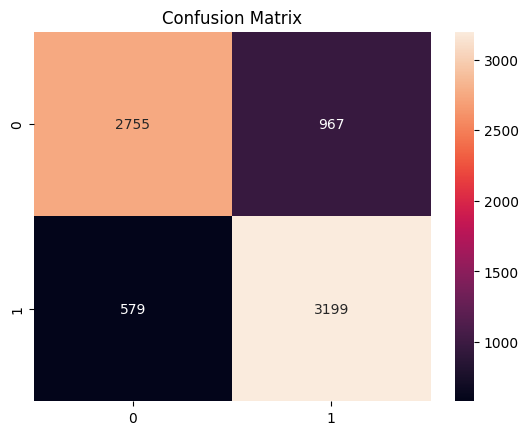

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# **Build LSTM Model**

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential()

# Embedding
model_lstm.add(Embedding(input_dim=10000, output_dim=64, input_length=200))

# LSTM layer
model_lstm.add(LSTM(64))

# Dropout
model_lstm.add(Dropout(0.5))

# Output
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 84s 149ms/step - accuracy: 0.7987 - loss: 0.4340 - val_accuracy: 0.8517 - val_loss: 0.3522
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 84s 153ms/step - accuracy: 0.8947 - loss: 0.2696 - val_accuracy: 0.8795 - val_loss: 0.3025
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 88s 160ms/step - accuracy: 0.9164 - loss: 0.2189 - val_accuracy: 0.8672 - val_loss: 0.3242
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 79s 145ms/step - accuracy: 0.9319 - loss: 0.1804 - val_accuracy: 0.8756 - val_loss: 0.3103


In [26]:
test_loss, test_acc_lstm = model_lstm.evaluate(X_test, y_test)

print("LSTM Test Accuracy:", test_acc_lstm)

235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8772 - loss: 0.2997
LSTM Test Accuracy: 0.8772000074386597


235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      3722
           1       0.85      0.93      0.88      3778

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500



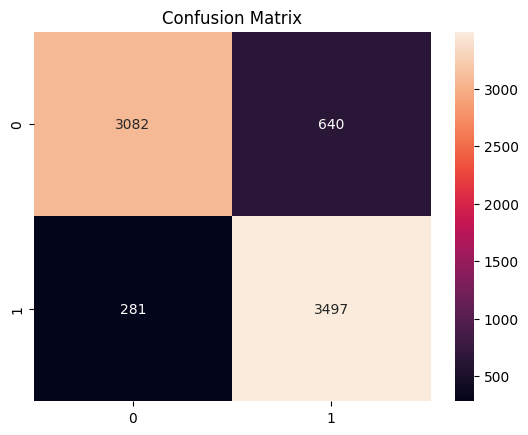

In [27]:
y_pred = (model_lstm.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# **Build GRU Model**

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

model_gru = Sequential()

# Embedding
model_gru.add(Embedding(input_dim=10000, output_dim=64, input_length=200))

# GRU layer
model_gru.add(GRU(64))

# Dropout
model_gru.add(Dropout(0.5))

# Output
model_gru.add(Dense(1, activation='sigmoid'))

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 106s 187ms/step - accuracy: 0.8031 - loss: 0.4151 - val_accuracy: 0.8717 - val_loss: 0.3270
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 97s 178ms/step - accuracy: 0.9025 - loss: 0.2498 - val_accuracy: 0.8884 - val_loss: 0.2755
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 96s 175ms/step - accuracy: 0.9293 - loss: 0.1915 - val_accuracy: 0.8881 - val_loss: 0.2946
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 97s 177ms/step - accuracy: 0.9497 - loss: 0.1430 - val_accuracy: 0.8836 - val_loss: 0.3020


In [31]:
test_loss, test_acc_gru = model_gru.evaluate(X_test, y_test)

print("GRU Test Accuracy:", test_acc_gru)

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8856 - loss: 0.2743
GRU Test Accuracy: 0.8855999708175659


235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      3722
           1       0.88      0.89      0.89      3778

    accuracy                           0.89      7500
   macro avg       0.89      0.89      0.89      7500
weighted avg       0.89      0.89      0.89      7500



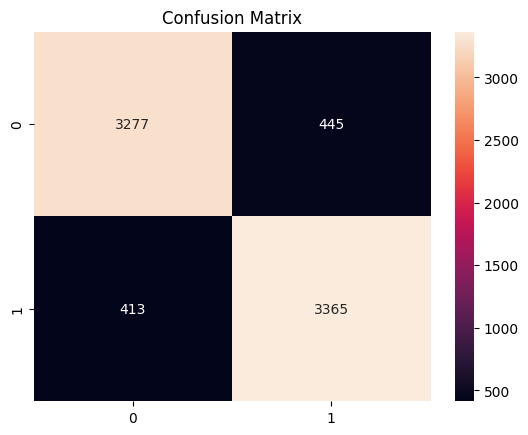

In [32]:
y_pred = (model_gru.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# **Model Comparison**

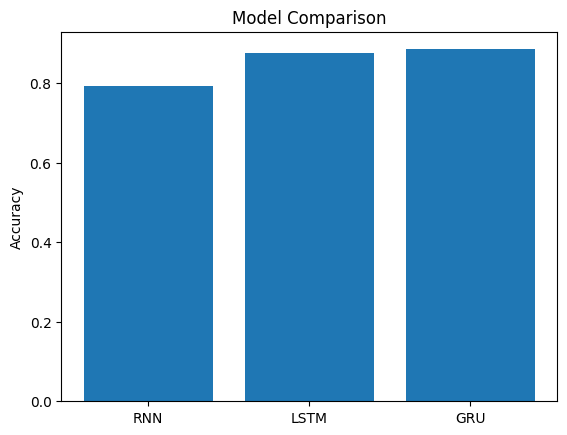

In [33]:
results = {
    "RNN": test_acc_rnn,
    "LSTM": test_acc_lstm,
    "GRU": test_acc_gru
}

plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

# **Save and Test Model**

In [34]:
# =========================
# Save trained models
# =========================

# Save RNN model
model.save("rnn_model.h5")

# Save LSTM model
model_lstm.save("lstm_model.h5")

# Save GRU model
model_gru.save("gru_model.h5")


In [35]:
import pickle
# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [48]:
from tensorflow.keras.models import load_model

# -------------------------
# Load trained models
# -------------------------
loaded_rnn = load_model("rnn_model.h5")
loaded_lstm = load_model("lstm_model.h5")
loaded_gru = load_model("gru_model.h5")

# -------------------------
# Load tokenizer
# -------------------------
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("Models and tokenizer loaded successfully!")

# -------------------------
# Prediction function
# -------------------------
def predict_sentiment(model, text):
    # Clean text using same preprocessing
    cleaned_text = clean_text(text)

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # Padding
    padded = pad_sequences(sequence, maxlen=200)

    # Prediction
    pred = model.predict(padded)[0][0]

    # Convert to label
    if pred > 0.5:
        return "Positive 😊", pred
    else:
        return "Negative 😡", pred

# -------------------------
# Test example
# -------------------------
text = "this movie was Bad"



Models and tokenizer loaded successfully!


In [49]:
# -------------------------
# Predictions
# -------------------------
print("RNN :", predict_sentiment(loaded_rnn, text))
print("LSTM:", predict_sentiment(loaded_lstm, text))
print("GRU :", predict_sentiment(loaded_gru, text))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
RNN : ('Negative 😡', np.float32(0.021460254))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
LSTM: ('Negative 😡', np.float32(0.21795425))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
GRU : ('Negative 😡', np.float32(0.18119273))
